## Introdução

O conjunto de dados de acidentes de trânsito, disponibilizado pela Polícia Rodoviária Federal (PRF) por meio do portal de dados abertos, reúne informações detalhadas sobre ocorrências em rodovias federais brasileiras. Esses dados são fundamentais para o monitoramento da segurança viária, planejamento de políticas públicas e análise de fatores associados à gravidade dos acidentes.

A natureza dessas informações permite a aplicação de métodos de aprendizado de máquina adequados para problemas de classificação, com destaque para o Random Forest, que possibilita investigar fatores associados à ocorrência de óbitos em acidentes de trânsito.

## O Banco de Dados

O banco de dados contém registros de acidentes de trânsito ocorridos no estado da Paraíba, contemplando variáveis relacionadas às características dos envolvidos e às condições do acidente, como sexo, tipo de envolvido, tipo de acidente, condição meteorológica, fase do dia e estado físico.

Essa estrutura possibilita a análise da ocorrência de óbitos nos acidentes, bem como a investigação de padrões associados a fatores comportamentais, ambientais e circunstanciais presentes no momento do sinistro.

## Modelagem Estatística (Random Forest)

A variável resposta principal — ocorrência de óbito — é caracterizada como uma variável binária, assumindo valores 0 (não óbito) e 1 (óbito). Nesse contexto, a análise é conduzida por meio do Random Forest, um método de aprendizado de máquina baseado em conjuntos de árvores de decisão, permitindo modelar a relação entre a variável resposta e um conjunto de covariáveis explicativas, como sexo, tipo de envolvido, tipo de acidente, condição meteorológica, fase do dia e estado físico.

O Random Forest estima a probabilidade de ocorrência de óbito por meio da agregação das predições de múltiplas árvores de decisão treinadas em amostras bootstrap do conjunto de dados, sendo amplamente utilizado em situações onde o interesse está na classificação de eventos binários com alta acurácia preditiva. Além disso, o modelo possibilita a interpretação da relevância das variáveis por meio das medidas de importância das variáveis (*feature importance*), como a diminuição média da impureza de Gini e a diminuição média da acurácia, permitindo identificar os fatores de maior contribuição para a predição dos acidentes fatais.

Essa abordagem possibilita a identificação de padrões relevantes e a avaliação do impacto das variáveis explicativas na probabilidade de ocorrência de óbitos, contribuindo para análises voltadas à segurança no trânsito.

In [ ]:
# @title

# Random Forest — Análise de Acidentes de Trânsito (PRF / Paraíba)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

df = pd.read_excel("acidentes_pb.xlsx")
df = df.dropna(how = 'all')
df.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,regiao
0,745197,2026-01-12,segunda-feira,09:40:00,PB,230,211.0,SOLEDADE,Ultrapassagem Indevida,Colisão lateral mesmo sentido,...,1,0,1,2,-7.075700,-36.339893,SPRF-PB,DEL02-PB,UOP02-DEL02-PB,interior
1,745655,2026-01-15,quinta-feira,00:04:00,PB,104,133.0,QUEIMADAS,Manobra de mudança de faixa,Outro,...,0,2,1,3,-7.308632,-35.893603,SPRF-PB,DEL02-PB,UOP03-DEL02-PB,interior
2,745988,2026-01-16,sexta-feira,13:50:00,PB,230,82.0,BAYEUX,Condutor deixou de manter distância do veículo...,Outro,...,8,0,1,4,-7.127942,-34.939545,SPRF-PB,DEL01-PB,UOP02-DEL01-PB,interior
3,745996,2026-01-16,sexta-feira,14:00:00,PB,230,150.0,CAMPINA GRANDE,Transitar na contramão,Outro,...,1,1,1,3,-7.259468,-35.878375,SPRF-PB,DEL02-PB,UOP01-DEL02-PB,interior
4,746126,2026-01-17,sábado,06:20:00,PB,230,13.0,CABEDELO,Retorno proibido,Colisão lateral mesmo sentido,...,0,1,1,2,-7.082288,-34.848795,SPRF-PB,DEL01-PB,UOP01-DEL01-PB,fronteira


Os dados apresentados na tabela a seguir descrevem as variáveis disponíveis no conjunto de dados de acidentes de trânsito da Polícia Rodoviária Federal (PRF) para o estado da Paraíba, contendo um total de  16,351 observações e 24 linhas. Cada variável possui uma classificação quanto ao tipo de dado, natureza e seu uso potencial em análises baseadas em modelos de classificação, como a Random forest. Essas informações são essenciais para compreender a estrutura do banco de dados e orientar as análises subsequentes e por isso são listadas algumas variaveis utilizadas na modelagem.

| Variável                   | Tipo de dado       | Natureza    | Característica                                                                                                                     |
| -------------------------- | ------------------ | ----------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| **sexo**                   | Categórica nominal | Qualitativa | Sexo do envolvido no acidente; pode indicar diferenças de comportamento e risco entre grupos                                       |
| **tipo_envolvido**         | Categórica nominal | Qualitativa | Classificação do envolvido (condutor, passageiro, pedestre, etc.); relevante para identificar perfis de maior vulnerabilidade      |
| **tipo_acidente**          | Categórica nominal | Qualitativa | Tipo de ocorrência (colisão, atropelamento, capotamento, etc.); variável fundamental para caracterização do evento                 |
| **condicao_metereologica** | Categórica nominal | Qualitativa | Condições climáticas no momento do acidente (chuva, céu claro, neblina, etc.); influencia a probabilidade de acidentes mais graves |
| **fase_dia**               | Categórica nominal | Qualitativa | Período do dia (dia, noite, amanhecer, entardecer); pode estar associado à visibilidade e risco de ocorrência                      |
| **Uso solo**          | Categórica nominal | Qualitativa | Condição que aconteceu o acidente de trasnito ( no solo de terra = sim, não = alfasto)         |
| **classificacao_acidente** | Categórica nominal | Qualitativa | Classificação geral do acidente quanto à gravidade; pode ser utilizada em análises de classificação multiclasse                    |



## Proporções de Acidentes por Tipo de Acidente

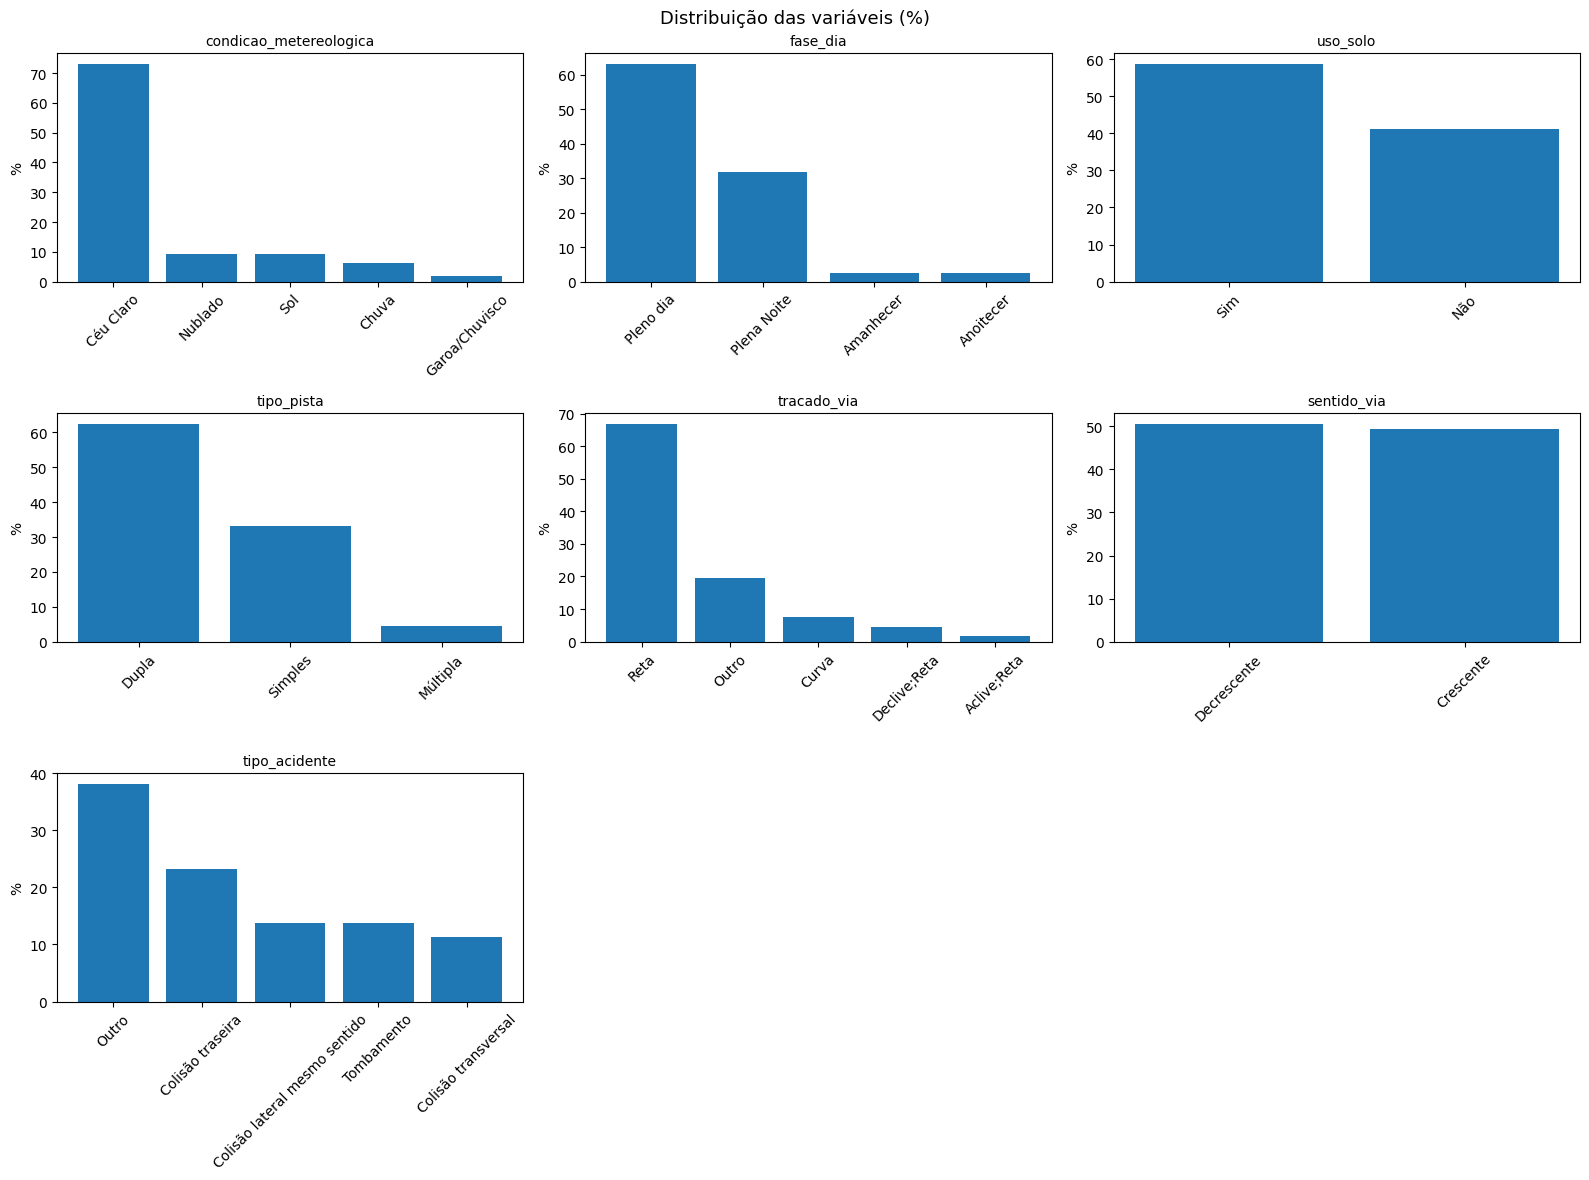

In [ ]:
# @title
import matplotlib.pyplot as plt

col_names = [
    "condicao_metereologica", "fase_dia", "uso_solo",
    "tipo_pista", "tracado_via", "sentido_via", "tipo_acidente"
]

top_n = {"tipo_acidente": 5, "tracado_via": 5}

def recodificar(series, n):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), other="Outro")

df_plot = df[col_names].copy()
for col, n in top_n.items():
    df_plot[col] = recodificar(df_plot[col], n)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(col_names):
    counts = df_plot[col].value_counts(normalize=True) * 100
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("%")
    axes[i].tick_params(axis="x", rotation=45)

axes[7].set_visible(False)
axes[8].set_visible(False)

plt.suptitle("Distribuição das variáveis (%)", fontsize=13)
plt.tight_layout()
plt.show()

a maioria dos acidentes na Paraíba ocorreu em condições de **céu claro** (~72%), durante o **pleno dia** (~62%) e em vias de **uso urbano** (~59%). As pistas eram predominantemente **duplas** (~62%) e com **traçado reto** (~68%), com sentido quase igualmente dividido entre decrescente e crescente.

Quanto ao tipo de acidente, a categoria **"Outro"** domina (~38%), seguida de **colisão traseira** (~23%) e **colisão lateral mesmo sentido** (~14%), sugerindo que os acidentes mais comuns envolvem veículos em movimento na mesma direção.

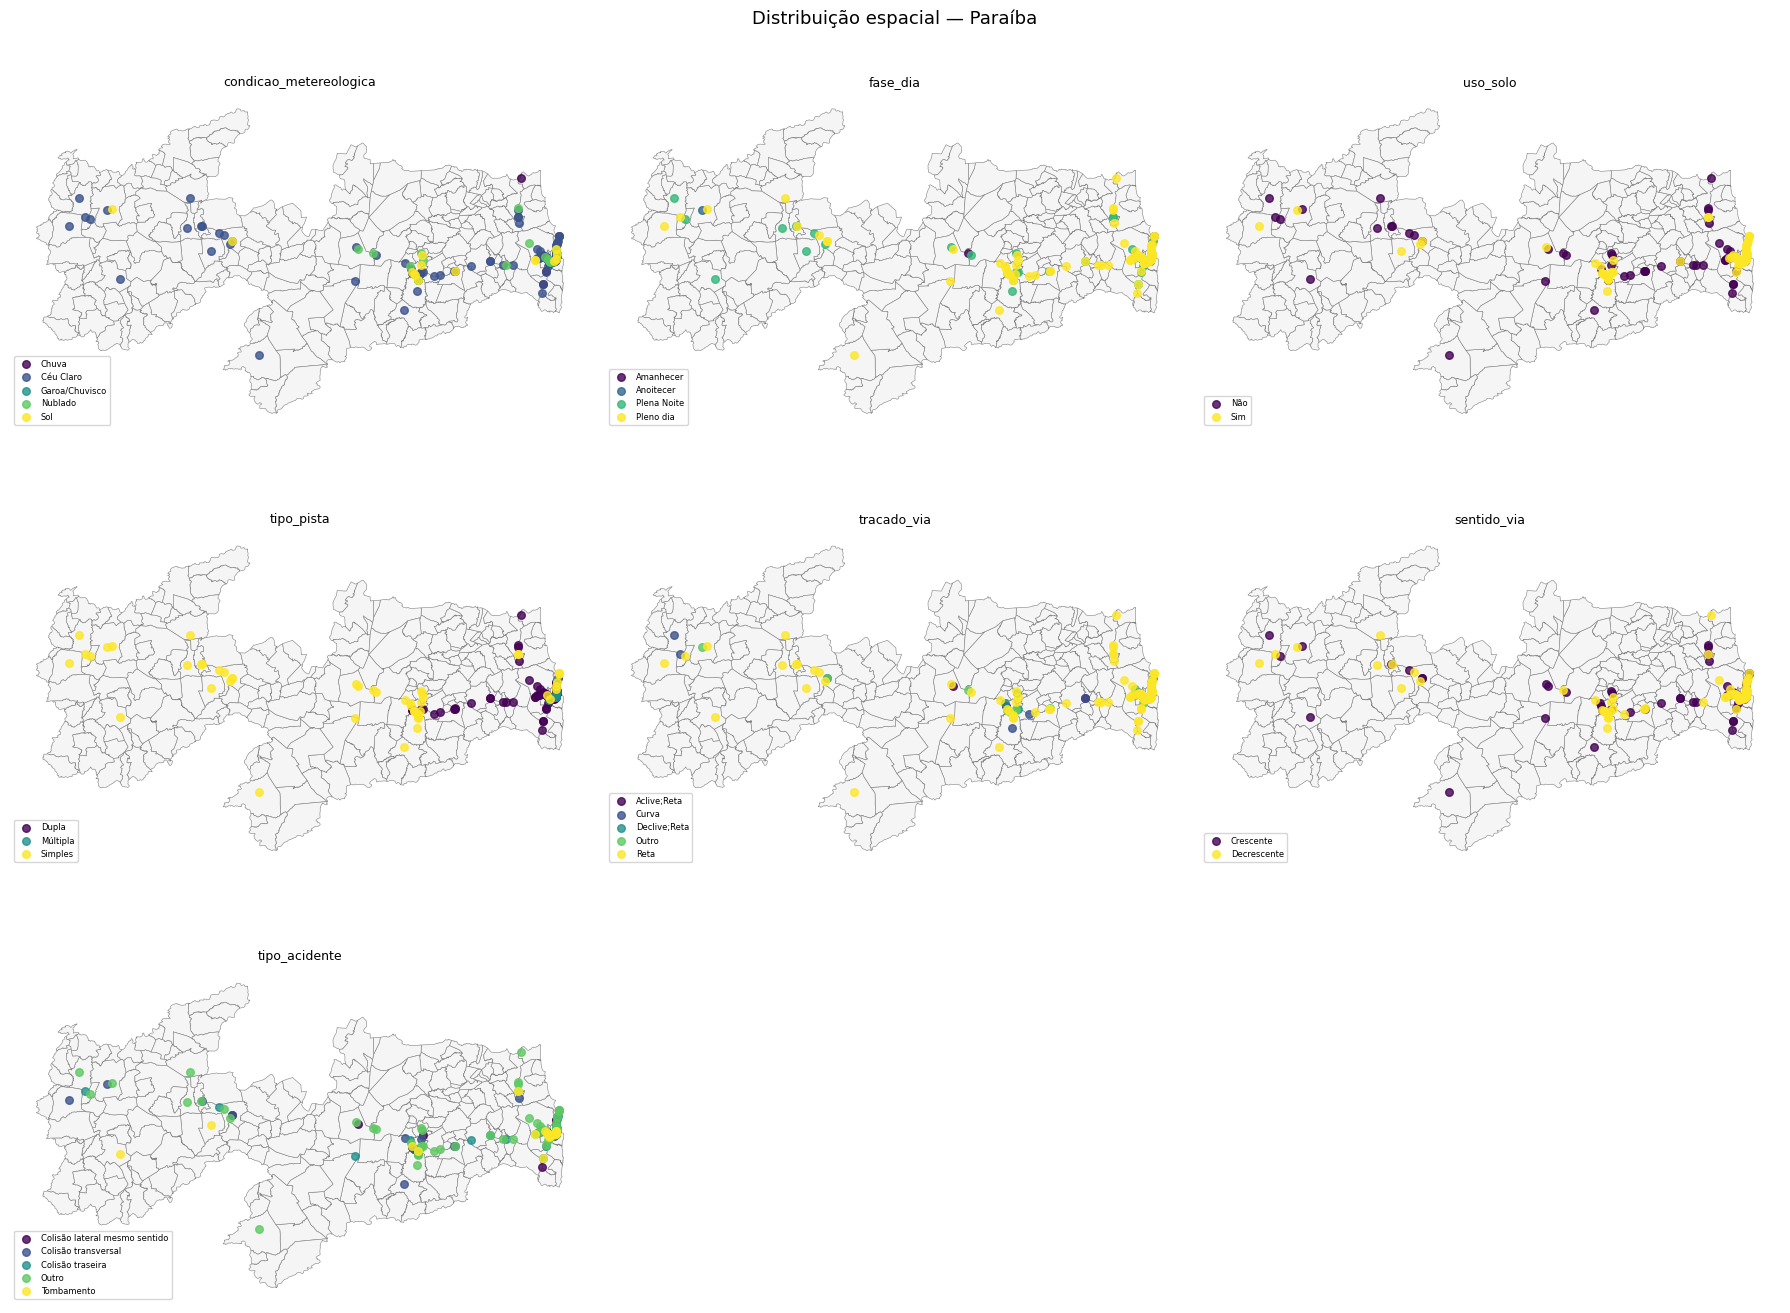

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

# baixa shapefile da Paraíba direto do IBGE
pb = gpd.read_file(
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/"
    "malhas_municipais/municipio_2022/UFs/PB/PB_Municipios_2022.zip"
)

col_names = [
    "condicao_metereologica", "fase_dia", "uso_solo",
    "tipo_pista", "tracado_via", "sentido_via", "tipo_acidente"
]

top_n = {"tipo_acidente": 5, "tracado_via": 5}

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(col_names):
    modo = df.groupby(["municipio", "latitude", "longitude"])[col] \
             .agg(lambda x: x.value_counts().index[0]).reset_index()

    if col in top_n:
        top = modo[col].value_counts().nlargest(top_n[col]).index
        modo[col] = modo[col].where(modo[col].isin(top), "Outro")

    cats = modo[col].astype("category")
    cores = plt.cm.viridis(np.linspace(0, 1, cats.cat.categories.size))

    # fundo do mapa
    pb.plot(ax=axes[i], color="whitesmoke", edgecolor="gray", linewidth=0.4)

    for cat, cor in zip(cats.cat.categories, cores):
        mask = modo[col] == cat
        axes[i].scatter(modo.loc[mask, "longitude"], modo.loc[mask, "latitude"],
                        color=cor, label=cat, s=30, alpha=0.8)

    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=6, loc="lower left")
    axes[i].axis("off")

axes[7].set_visible(False)
axes[8].set_visible(False)

plt.suptitle("Distribuição espacial — Paraíba", fontsize=13)
plt.tight_layout()
plt.show()

Os mapas revelam uma concentração clara de acidentes na **faixa litorânea e agreste** (região leste do estado), especialmente nos municípios próximos a João Pessoa, Campina Grande e Santa Rita, com poucos registros no sertão e cariri.

- **Condição meteorológica**: céu claro domina em praticamente todo o estado, com chuva e garoa concentradas no leste, região com maior umidade.
- **Fase do dia**: pleno dia é predominante em quase todos os municípios, mas plena noite aparece com mais frequência no eixo litorâneo, possivelmente associado ao maior fluxo noturno nessa região.
- **Uso do solo**: o uso urbano (amarelo) se concentra no leste e litoral, enquanto o rural aparece mais disperso no interior — coerente com a distribuição populacional do estado.
- **Tipo de pista**: pistas duplas predominam no leste e nas rodovias federais, enquanto pistas simples são mais comuns no interior.
- **Traçado da via**: retas dominam em toda a extensão, com curvas e declives aparecendo pontualmente no agreste e brejo.
- **Tipo de acidente**: colisões traseiras e "Outro" estão espalhados por todo o estado, mas tombamentos aparecem mais no interior, possivelmente associados a vias rurais e cargas.

## Trasnformar os níveis das variaveis para multiplos niveis OrdinalEncoder


In [ ]:
# @title
from sklearn.preprocessing import OrdinalEncoder

# Variáveis explicativas
cols_X = [
    "condicao_metereologica", "fase_dia", "uso_solo",
    "tipo_pista", "tracado_via", "sentido_via", "tipo_acidente"
]

# Variável resposta
col_y = "classificacao_acidente"

# Criar base
df_modelo = df[cols_X + [col_y]].copy()

# Separar X
X = df_modelo[cols_X]

# Aplicar encoding (em TODAS categóricas) e Converter de volta para DataFrame

encoder = OrdinalEncoder()
X = encoder.fit_transform(X)
X = pd.DataFrame(X, columns=cols_X)
X = X.astype("category")

# Atualizar no df_modelo
df_modelo[cols_X] = X
df_modelo = df_modelo.dropna()
df_modelo.head(10)

,condicao_metereologica,fase_dia,uso_solo,tipo_pista,tracado_via,sentido_via,tipo_acidente,classificacao_acidente
0,3.0,3.0,0.0,2.0,0.0,0.0,0.0,Com Vítimas Feridas
1,1.0,2.0,0.0,2.0,4.0,1.0,3.0,Com Vítimas Feridas
2,1.0,3.0,0.0,0.0,4.0,0.0,3.0,Com Vítimas Feridas
3,0.0,3.0,1.0,2.0,3.0,1.0,3.0,Com Vítimas Feridas
4,3.0,3.0,1.0,0.0,3.0,1.0,0.0,Com Vítimas Feridas
5,1.0,2.0,0.0,2.0,4.0,0.0,3.0,Com Vítimas Feridas
6,1.0,2.0,1.0,2.0,3.0,0.0,0.0,Com Vítimas Feridas
7,1.0,3.0,0.0,0.0,4.0,0.0,3.0,Sem Vítimas
8,1.0,3.0,1.0,2.0,4.0,0.0,3.0,Com Vítimas Feridas
9,1.0,3.0,0.0,2.0,4.0,0.0,2.0,Com Vítimas Fatais


## dividino a base para as variáveis preditoras

In [ ]:
X = df_modelo.drop("classificacao_acidente", axis=1); X = X.dropna()
y = df_modelo["classificacao_acidente"]; y = y.dropna()


Inicialmente, foi realizada a divisão da base de dados, separando as variáveis preditoras da variável resposta. Esse procedimento é fundamental para a construção dos modelos, pois permite utilizar as informações explicativas de forma estruturada na etapa de treinamento e avaliação.Inicialmente, foi realizada a divisão da base de dados, separando as variáveis preditoras da variável resposta. Esse procedimento é fundamental para a construção dos modelos, pois permite utilizar as informações explicativas de forma estruturada na etapa de treinamento e avaliação.

## treino e teste

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

Posteriormente, a base de dados foi dividida em conjuntos de treino e teste. O conjunto de treino foi utilizado para ajustar o modelo, enquanto o conjunto de teste foi reservado para avaliar seu desempenho em dados não observados, permitindo uma análise mais realista da capacidade de generalização do modelo.

## treinando o Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 8,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 5,
 'min_samples_split': 10,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

**Estrutura da floresta**
O modelo constrói 300 árvores, cada uma treinada em uma amostra aleatória com reposição, usando todos os núcleos do processador em paralelo. Em cada divisão considera apenas a raiz quadrada do número de variáveis disponíveis, aumentando a diversidade entre as árvores e reduzindo a correlação entre elas.

**Controle de crescimento**
O crescimento de cada árvore é limitado por profundidade máxima de 8 níveis, mínimo de 10 amostras para dividir um nó e mínimo de 5 amostras em cada folha. Esses três parâmetros funcionam como regularização natural, evitando overfitting sem necessidade de poda explícita.

**Critério de divisão**
A qualidade de cada split é medida pelo índice Gini, que avalia o grau de mistura entre as classes em cada nó e guia o modelo a escolher as divisões mais informativas.

**Desbalanceamento**
O parâmetro class_weight='balanced' ajusta automaticamente os pesos de cada classe de forma inversamente proporcional à sua frequência, fazendo com que classes raras recebam mais atenção durante o treinamento e evitando que o modelo ignore as minorias.

**Reprodutibilidade**
O random_state=42 garante que os resultados sejam idênticos em qualquer execução futura, permitindo que o experimento seja replicado com exatamente os mesmos resultados.

## Avalaliando o RF

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)

print(classification_report(y_test, y_pred))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro"), 4))

                     precision    recall  f1-score   support

 Com Vítimas Fatais       0.25      0.50      0.33         4
Com Vítimas Feridas       0.85      0.59      0.70        39
        Sem Vítimas       0.15      0.40      0.22         5

           accuracy                           0.56        48
          macro avg       0.42      0.50      0.42        48
       weighted avg       0.73      0.56      0.62        48

AUC-ROC: 0.6426


O modelo foi avaliado sobre **48 registros de teste**, com três classes: **Com Vítimas Fatais**, **Com Vítimas Feridas** e **Sem Vítimas**. O **AUC-ROC de 0.6426** indica **capacidade discriminativa moderada**, coerente com a dificuldade de separação entre as classes no problema multiclasse.

A **acurácia geral de 56%** é relativamente modesta e **não deve ser analisada isoladamente**, pois há **desbalanceamento relevante**: a classe *Com Vítimas Feridas* representa a maior parte da amostra (39 de 48 observações, ~81%), o que tende a inflar métricas globais sem refletir desempenho real nas classes minoritárias.

A classe **Com Vítimas Feridas** foi a mais bem capturada pelo modelo, com **precisão de 85%** — ou seja, quando o modelo prevê essa classe, ele geralmente acerta. No entanto, o **recall de 59%** mostra que cerca de **41% dos casos reais de acidentes com feridos não são identificados**, sendo confundidos com outras classes. O **F1-score de 0.70** indica um desempenho razoável, mas ainda com perda significativa de sensibilidade.

Para **Com Vítimas Fatais**, o modelo apresenta **recall de 50%**, ou seja, identifica metade dos casos fatais. A **precisão de 25%** é baixa, indicando presença de falsos positivos — para cada acerto, há vários alarmes incorretos. O **F1-score de 0.33** reflete esse desequilíbrio. Ainda assim, em aplicações de segurança viária, um recall mais alto pode ser desejável, mesmo ao custo de menor precisão.

A classe **Sem Vítimas** apresenta desempenho fraco: **precisão de 15%** e **recall de 40%**, com **F1-score de 0.22**. Isso sugere que o modelo tem dificuldade em distinguir acidentes sem vítimas, possivelmente porque os preditores disponíveis não capturam bem os fatores determinantes desse tipo de ocorrência.

O **F1-score macro de 0.42** confirma que o modelo possui **baixo equilíbrio entre as classes**, penalizado principalmente pelo desempenho nas classes minoritárias. Já o **F1-score ponderado de 0.62** é superior, mas reflete fortemente o bom desempenho na classe majoritária.


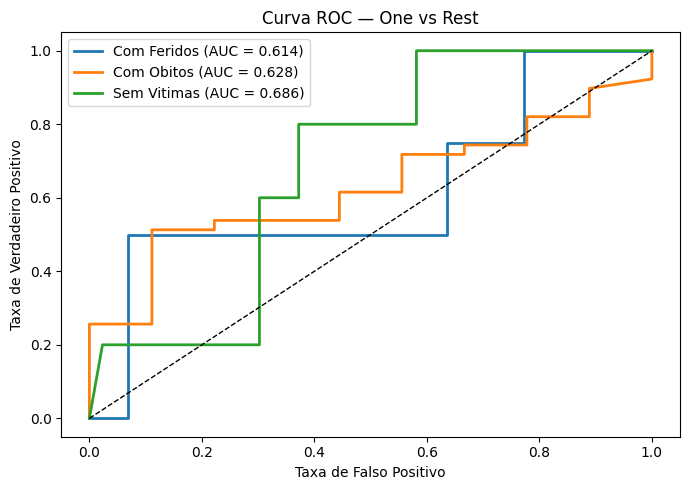

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binariza y_test para OvR
y_bin = label_binarize(y_test, classes=rf.classes_)
nomes = ["Com Feridos", "Com Obitos", "Sem Vitimas"]

fig, ax = plt.subplots(figsize=(7, 5))

for i, nome in enumerate(nomes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, lw=2, label=f"{nome} (AUC = {auc(fpr, tpr):.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("Taxa de Falso Positivo")
ax.set_ylabel("Taxa de Verdadeiro Positivo")
ax.set_title("Curva ROC — One vs Rest")
ax.legend()
plt.tight_layout()
plt.show()


**Com Feridos (AUC = 0.614)** apresentou desempenho moderado, porém inferior ao observado anteriormente. Mesmo sendo a classe majoritária, o modelo demonstra dificuldade em separar completamente essa classe das demais, sugerindo sobreposição relevante no espaço das variáveis explicativas.

**Com Óbitos (AUC = 0.628)** teve desempenho ligeiramente superior ao de *Com Feridos*, mas ainda dentro de um nível **moderado de discriminação**. O modelo consegue distinguir acidentes fatais melhor que o acaso, porém com limitações claras — reforçando a hipótese de similaridade estrutural entre acidentes com óbitos e com feridos.

**Sem Vítimas (AUC = 0.686)** foi a classe **mais bem discriminada neste cenário**, indicando que o modelo está conseguindo capturar melhor os padrões associados à ausência de vítimas, ainda que não de forma robusta. Esse resultado contrasta com análises anteriores e pode refletir variabilidade amostral (amostra de teste pequena) ou mudanças no ajuste do modelo.

O **AUC macro aproximado de 0.64** confirma que o modelo possui **capacidade discriminativa moderada no geral**, com desempenho relativamente equilibrado entre as classes, mas ainda distante de um nível considerado forte.




## importancia das variáveis

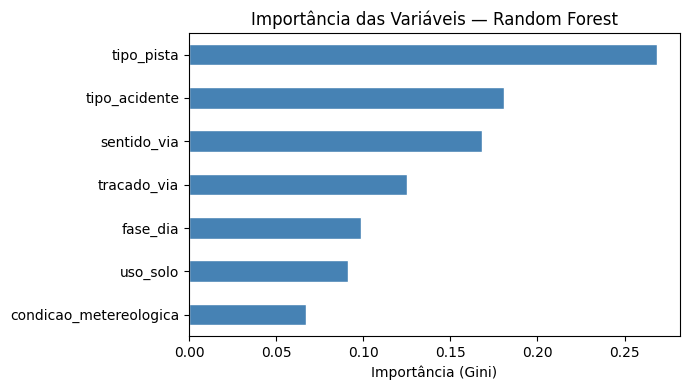

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

features = col_X

imp = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Importância (Gini)")
ax.set_title("Importância das Variáveis — Random Forest")
plt.tight_layout()
plt.show()


**tipo_pista (≈ 0.27)** é, de forma destacada, o principal discriminador da gravidade dos acidentes. Esse resultado é consistente do ponto de vista estrutural: características da via (pista simples vs. duplicada, presença de acostamento, etc.) estão diretamente associadas ao risco e à severidade dos eventos.

**tipo_acidente (≈ 0.18)** aparece como a segunda variável mais relevante, indicando que a natureza do acidente (colisão frontal, traseira, saída de pista, etc.) carrega forte informação sobre o desfecho em termos de vítimas.

**sentido_via (≈ 0.17)** também apresenta alta importância, sugerindo que a configuração do fluxo (mão dupla vs. sentido único) influencia significativamente a probabilidade de maior gravidade — novamente coerente com maior risco de colisões frontais.

**tracado_via (≈ 0.13)** ocupa uma posição intermediária, refletindo o efeito de curvas, retas e outros elementos geométricos na dinâmica do acidente.

**fase_dia (≈ 0.10)** e **uso_solo (≈ 0.09)** apresentam contribuições menores, mas ainda relevantes. Parte do efeito dessas variáveis pode estar sendo capturada indiretamente por variáveis mais estruturais (como tipo de pista e tipo de acidente), o que reduz sua importância marginal no critério de Gini.

Por fim, **condicao_metereologica (≈ 0.07)** foi a menos relevante no modelo, sugerindo que, dentro desta base específica, as condições climáticas têm menor poder discriminativo em comparação com fatores estruturais da via e características do acidente.


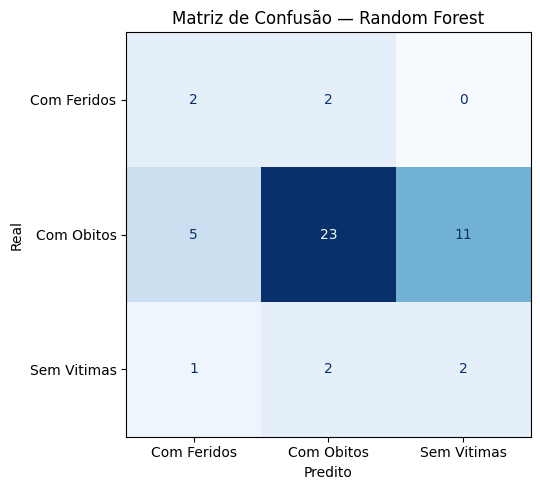

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Com Feridos", "Com Obitos", "Sem Vitimas"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de Confusão — Random Forest")
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()